# K-Nearest Neighbors (KNN) — From Scratch

A hands-on implementation of the KNN classification algorithm built with NumPy.  
Three decision strategies are compared on a 2-class synthetic dataset:

| Strategy | Description |
|---|---|
| **Nearest Neighbor** | Assign the class of the single closest point |
| **KNN Majority Vote (k=5)** | Majority class among the 5 nearest neighbors |
| **KNN Average Distance (k=5)** | Assign the class whose 5 nearest neighbors are on average closer |


## 1. Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math

## 2. Generate Synthetic Data

We create two classes — **Red** and **Blue** — as noisy square-root curves along the x-axis.  
Both classes grow with x, but Red starts higher (`2x + 6`) and Blue starts lower (`2x + 1`),  
making them separable with some overlap.  
An extra Red outlier point is added at `(8, 1)` to test boundary robustness.


In [2]:
x = np.linspace(0, 10, 50)

red  = np.sqrt(2*x + 6 + np.random.normal(0, 1, 50))
bleu = np.sqrt(2*x + 1 + np.random.normal(0, 1, 50))

# Add an outlier red point at (8, 1)
red = np.append(red, 1)
X   = np.append(x, 8)

RED  = np.vstack((X, red)).T
BLEU = np.vstack((x, bleu)).T

## 3. Quick Preview of the Data

Scatter plot to verify the class distributions before classification.


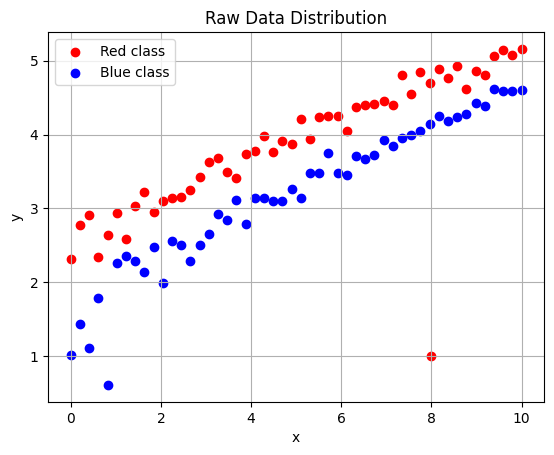

In [3]:
plt.scatter(RED[:, 0],  RED[:, 1],  c="red",  label="Red class")
plt.scatter(BLEU[:, 0], BLEU[:, 1], c="blue", label="Blue class")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Raw Data Distribution")
plt.legend()
plt.grid(True)
plt.show()

## 4. KNN Classification Functions

Three functions implement different KNN decision rules.  
All take the Red point-cloud `R`, Blue point-cloud `B`, and a query point `p`.  
They return `0` for Red and `1` for Blue.

### 4.1 — Nearest Neighbor (k = 1)
Assigns the class of the **single** nearest data point.

### 4.2 — KNN Majority Vote (k = 5)
Collects the 5 nearest points across both classes and picks the **majority class**.

### 4.3 — KNN Average Distance (k = 5)
Picks the top-5 from each class separately and assigns the class with the **smaller average distance**.


In [4]:
def destanceTop5(R, B, p):
    """KNN Majority Vote — k=5."""
    dist_Red  = np.sqrt(np.power(R[:,0] - p[0], 2) + np.power(R[:,1] - p[1], 2))
    dist_Blue = np.sqrt(np.power(B[:,0] - p[0], 2) + np.power(B[:,1] - p[1], 2))

    minR = np.sort(dist_Red)[:5]
    minB = np.sort(dist_Blue)[:5]

    color  = np.concatenate((np.zeros(5), np.ones(5)))   # 0=Red, 1=Blue
    Min    = np.concatenate((minR, minB))

    Points        = np.vstack((Min, color))
    Points_sorted = Points[:, np.argsort(Points[0, :])]
    top_5         = Points_sorted[:, :5]

    return 1 if np.sum(top_5[1, :]) >= 3 else 0


def destanceAvrage(R, B, p):
    """KNN Average Distance — k=5."""
    dist_Red  = np.sqrt(np.power(R[:,0] - p[0], 2) + np.power(R[:,1] - p[1], 2))
    dist_Blue = np.sqrt(np.power(B[:,0] - p[0], 2) + np.power(B[:,1] - p[1], 2))

    avgMinR = np.average(np.sort(dist_Red)[:5])
    avgMinB = np.average(np.sort(dist_Blue)[:5])

    return 0 if avgMinR < avgMinB else 1


def destance(R, B, p):
    """Nearest Neighbor — k=1."""
    dist_Red  = np.sqrt(np.power(R[:,0] - p[0], 2) + np.power(R[:,1] - p[1], 2))
    dist_Blue = np.sqrt(np.power(B[:,0] - p[0], 2) + np.power(B[:,1] - p[1], 2))

    return 0 if min(dist_Red) < min(dist_Blue) else 1

## 5. Build the Query Grid

We create a dense grid of points covering the data space.  
Each point will be classified by all three strategies to visualise the **decision boundaries**.


In [5]:
List = []
for i in range(101):
    for j in range(int(max(np.max(red), np.max(bleu))) * 10 + 3):
        List.append([i / 10, j / 10])

points = np.array(List)
print(f"Grid size: {len(points):,} points")

Grid size: 5,353 points


## 6. Classify Every Grid Point

Run all three classifiers on the grid and collect Red/Blue lists for each strategy.


In [6]:
Re_list, Bl_list = [], []   # Majority Vote (k=5)
R_list,  B_list  = [], []   # Average Distance (k=5)
RE_list, BL_list = [], []   # Nearest Neighbor (k=1)

for p in points:
    if destanceTop5(RED, BLEU, p) == 0:
        Re_list.append(p)
    else:
        Bl_list.append(p)

    if destanceAvrage(RED, BLEU, p) == 0:
        R_list.append(p)
    else:
        B_list.append(p)

    if destance(RED, BLEU, p) == 0:
        RE_list.append(p)
    else:
        BL_list.append(p)

# Stack grid points with original data for plotting
Re = np.vstack((RED, np.array(Re_list))).T;  Bl = np.vstack((BLEU, np.array(Bl_list))).T
R  = np.vstack((RED, np.array(R_list))).T;   B  = np.vstack((BLEU, np.array(B_list))).T
RE = np.vstack((RED, np.array(RE_list))).T;  BL = np.vstack((BLEU, np.array(BL_list))).T

## 7. Compare Decision Boundaries

The 2×2 grid shows:
- **Top-left** — raw data distribution  
- **Top-right** — KNN Majority Vote boundary (k=5)  
- **Bottom-left** — KNN Average Distance boundary (k=5)  
- **Bottom-right** — Nearest Neighbor boundary (k=1)

Original training points are highlighted in **yellow** (Red class) and **black** (Blue class).


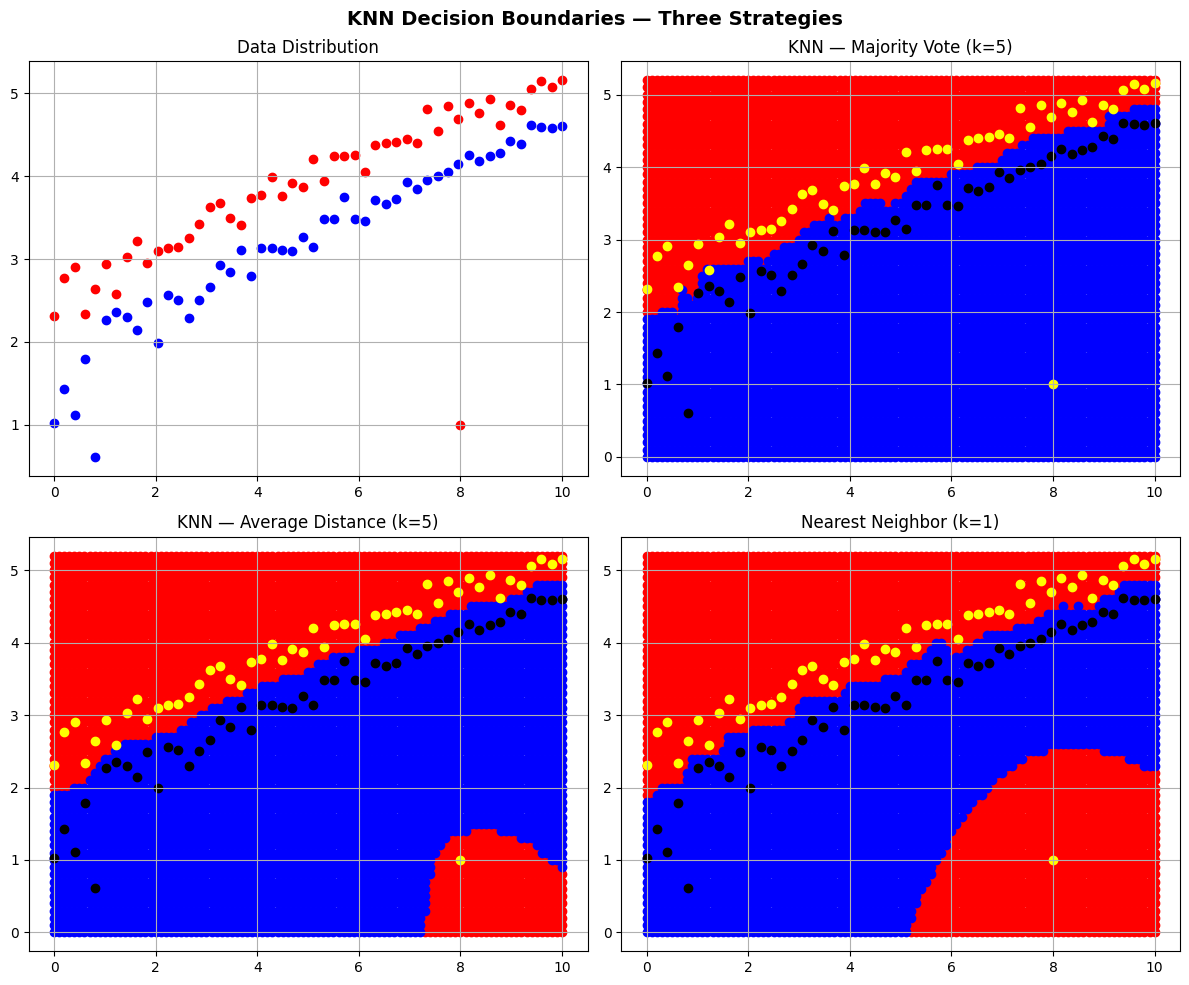

In [7]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

# Raw data
ax1.scatter(RED[:, 0],  RED[:, 1],  c="red")
ax1.scatter(BLEU[:, 0], BLEU[:, 1], c="blue")
ax1.set_title("Data Distribution"); 
ax1.grid(True)

# KNN Majority Vote
ax2.scatter(Re[0], Re[1], c="red")
ax2.scatter(Bl[0], Bl[1], c="blue")
ax2.scatter(RED[:, 0],  RED[:, 1],  c="yellow")
ax2.scatter(BLEU[:, 0], BLEU[:, 1], c="black")
ax2.set_title("KNN — Majority Vote (k=5)"); 
ax2.grid(True)

# KNN Average Distance
ax3.scatter(R[0], R[1], c="red")
ax3.scatter(B[0], B[1], c="blue")
ax3.scatter(RED[:, 0],  RED[:, 1],  c="yellow")
ax3.scatter(BLEU[:, 0], BLEU[:, 1], c="black")
ax3.set_title("KNN — Average Distance (k=5)"); 
ax3.grid(True)

# Nearest Neighbor
ax4.scatter(RE[0], RE[1], c="red")
ax4.scatter(BL[0], BL[1], c="blue")
ax4.scatter(RED[:, 0],  RED[:, 1],  c="yellow")
ax4.scatter(BLEU[:, 0], BLEU[:, 1], c="black")
ax4.set_title("Nearest Neighbor (k=1)"); 
ax4.grid(True)

plt.suptitle("KNN Decision Boundaries — Three Strategies", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()